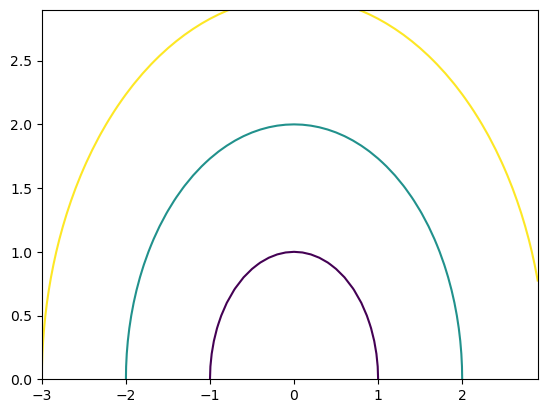

In [1]:
import numpy as np
import matplotlib.pyplot as plt

xx=np.arange(-3,3,0.1);len(xx)
yy=np.arange(0,3,0.1);len(yy)
zz=[]
for y in yy:
    for x in xx:
        zz.append([np.sqrt(x**2 + y**2)])
zz=np.array(zz)
zz=zz.reshape(len(yy),len(xx))
zz
plt.contour(xx, yy, zz, [1,2,3])

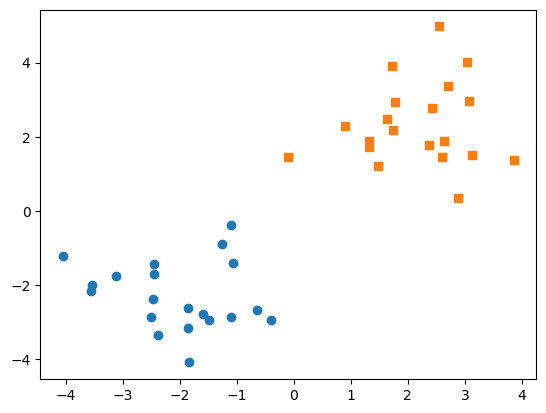

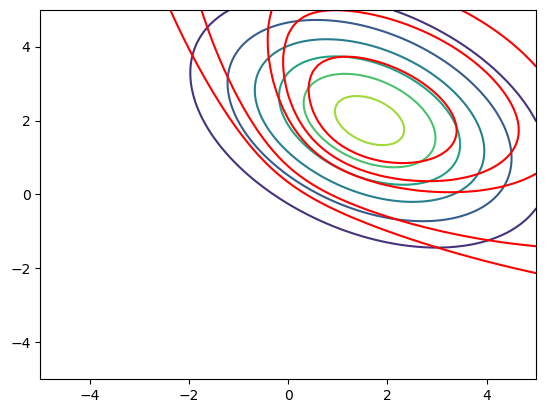

881.7749926669931


In [2]:
# hw
from matplotlib import pyplot as plt
from scipy.stats import multivariate_normal
import numpy as np
import sympy as sp
import pandas as pd
from timeit import default_timer as timer 

data=np.array(pd.read_csv('//Users/liaoweihong/Desktop/Python/DAML/data4.csv', header=None))
y=data[:,0]; x=np.array(data[:,1:3]); sig2=10;
plt.scatter(x[y==0][:,0], x[y==0][:,1],marker='o')
plt.scatter(x[y==1][:,0], x[y==1][:,1],marker='s')
plt.show()

w1=sp.Symbol('w1'); w2=sp.Symbol('w2');
prior=(-w1**2/sig2-w2**2/sig2)/2-sp.log(2*np.pi*sig2)
logg=prior;
for i in range(len(y)):
    logg = logg - y[i]*sp.log(1+sp.exp(-w1*x[i,0]-w2*x[i,1])) + (1-y[i])*((-w1*x[i,0]-w2*x[i,1])-sp.log(1+sp.exp(-w1*x[i,0]-w2*x[i,1]))) 
ans=sp.nsolve((sp.diff(logg, w1), sp.diff(logg, w2)), (w1,w2), (1.45,1.8))

what=np.array([ans[0,0],ans[1,0]]);
FI=-sp.Matrix([[sp.diff(sp.diff(logg, w1), w1),sp.diff(sp.diff(logg, w1), w2)],[sp.diff(sp.diff(logg, w1), w2),sp.diff(sp.diff(logg, w2), w2)]])
COV=FI.subs([(w1,what[0]), (w2,what[1])]).inv()

w1v=np.linspace(-5,5,101);len(w1v)
w2v=np.linspace(-5,5,101);len(w2v)
zz=[]; truezz=[];
start = timer()
for yy in w2v:
    for xx in w1v:
        zz.append([multivariate_normal.pdf([xx,yy],what,COV)])
        truezz.append([float(logg.subs([(w1,xx), (w2,yy)]))])
zz=np.array(zz); truezz=np.array(truezz);
zz=zz.reshape(len(w2v),len(w1v));
truezz=truezz.reshape(len(w2v),len(w1v));
CS = plt.contour(w1v, w2v, zz)
CS2 = plt.contour(w1v, w2v, truezz,[-20,-12,-6,-5.5,-5],colors=['#ff0000', '#ff0000', '#ff0000', '#ff0000','#ff0000'])
plt.show()
print(timer()-start)

